In [12]:
import yaml
import os
from datetime import datetime
from loguru import logger  
import torch 
import torch.nn as nn 
import pandas as pd
from torchvision import transforms
from tqdm import tqdm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from src.utils.utils import load_config
from src.data.loader import bigearthnet_loader, bigearthnet_DataModule
from src.utils.torch import seed_everything
from src.model_zoo.models import define_model_, define_model_scratch
from src.metrics.metrics import MultiLabelMetrics
from src.utils.wandb_logger import WandbLogger
from src.loader.reader import Dataset_BigEarthNet, Reader
from src.loader.reader import means_s2, stds_s2, get_list_means_std, get_right_dict, label_to_idx

In [13]:
## Build up model by definition 
def reader_(config_dataset, name_selected_bands):
    """ Create a class that handles the retrieval of tif files. 
    """
    reader = Reader(
        root_folder_path=config_dataset["datasets"]["root"],
        metadata_parquet_path = config_dataset["datasets"]["metadata_parquet"]
    )
    return reader 

def loader_dataset(train_test_split:str,reader, config, name_selected_bands,
                    list_mean, list_std, label_to_idx, small_fraction=None):
    """
    Create a torch DataSet class that will iterate be passed on a datamodule
    """
    return Dataset_BigEarthNet(
        reader= reader,
        strip_bands = name_selected_bands,
        img_size=config["datasets"]["img_size"],
        upsample_mode=config["datasets"]["upsampling_method"],
        normalize =True,
        split_train_test= train_test_split,
        dict_one_hot= label_to_idx,
        small_fraction=small_fraction,
        transform= transforms.Compose([
           transforms.Normalize(mean=list_mean, std=list_std),
            transforms.Resize([224,224])
        ])
        )

def loader_dataloader(dataset,**kwargs):
    return DataLoader(
            dataset = dataset,
            **kwargs
        )
## It uses segmentation-models-torch to create the class that is by itself a nn.Torch
def build_model(config):


    # model = define_model_(
    #     model_name = config['model']['model_name'],
    #     num_classes = config['model']['num_classes'],
    #     input_channels =  config['model']['in_channels'],
    #     weights = config['model']['weight'],
    #     bands = config['model']['sentinel2_bands'],
    #     selected_channels = config['model']['select_bands']
    # )
    model = define_model_scratch(
        model_name = config['model']['model_name'],
        out_channel= config['model']['num_classes'],
        in_channel= config['model']['in_channels'],
        pretrained=config['model']['pretrained']
    )
    logger.info('Model created sucesfully')
    if config['model']['pretrained']:
        logger.info(model.pretrained_cfg)

    ## gpu 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    return model, device


def build_opt(model, config, pos_weight):
    optimizer_class = getattr(torch.optim, config['training']['optim'])

    ## weight decay
    weight_decay = config['training'].get('weight_decay', 0)

    if config['training']['optim'] == 'Adam':
        optimizer = optimizer_class(
            model.parameters(),
            lr=float(config['training']['learning_rate']),
            weight_decay=float(weight_decay)
        )
    elif config['training']['optim'] == 'SGD':
        logger.info(f"Adding Momentum to the given optimizer")
        optimizer = optimizer_class(
            model.parameters(),
            lr=float(config['training']['learning_rate']),
            momentum = config['training']['momentum_val'],
            weight_decay= float(weight_decay)
        )

    logger.info(f"Weight decay: {weight_decay}")

    scheduler = config['training']['scheduler']
    scheduler_class = None

    if scheduler:
        logger.info(f"scheduler type: {config['training']['scheduler_type']}")
        logger.info(f"scheduler factor: {config['training']['factor']}")
        
        lr_scheduler = getattr(torch.optim.lr_scheduler, config['training']['scheduler_type'])
        
        # For ReduceLROnPlateau, add patience parameter
        if config['training']['scheduler_type'] == 'ReduceLROnPlateau':
            patience = config['training'].get('patience', 10)  #patience of 10
            scheduler_class = lr_scheduler(
                optimizer, 
                mode='min', 
                factor=config['training']['factor'],
                patience=patience
            )
            logger.info(f"scheduler patience: {patience}")
        else:
            #change this if the scheduler is not ReduceLRonPlateaou
            scheduler_class = lr_scheduler(optimizer, factor=config['training']['factor'])

    ### Cross Entropy 
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion=nn.BCEWithLogitsLoss()

    return optimizer, criterion, scheduler, scheduler_class


def train_epoch(model, train_loader, optimizer, criterion, device, metrics_tracker, sensitivity):
    model.train()
    metrics_tracker.reset()
    train_loss = 0.0

    with tqdm(total=len(train_loader.dataset), ncols=100, colour='#3eedc4') as t:
        t.set_description("Training")
        for x_data, y_data in train_loader:
            x_data, y_data = x_data.to(device), y_data.to(device)
            optimizer.zero_grad()
            outputs = model(x_data)
            loss = criterion(outputs, y_data.squeeze().float()) ## add loss 
            loss.backward() #compute gradient
            optimizer.step()

            out_sigmoid = torch.sigmoid(outputs)
            outputs_sens = (out_sigmoid>sensitivity).float()

            metrics_tracker.update(outputs_sens, y_data.squeeze())
            train_loss += loss.item()
            t.set_postfix(loss=loss.item())
            t.update(x_data.size(0))

    return train_loss / len(train_loader), metrics_tracker.compute()

def train_epoch_debug(model, train_loader, optimizer, criterion, device, metrics_tracker, sensitivity):
    model.train()
    metrics_tracker.reset()
    train_loss = 0.0

    with tqdm(total=len(train_loader.dataset), ncols=100, colour='#3eedc4') as t:
        t.set_description("Training")
        for batch_idx, (x_data, y_data) in enumerate(train_loader):
            x_data, y_data = x_data.to(device), y_data.to(device)
            
            optimizer.zero_grad()
            outputs = model(x_data)

            loss = criterion(outputs, y_data.squeeze().float())

            # Debug loss and gradients
            if batch_idx == 0:
                print(f"Loss value: {loss.item()}")
                print(f"Model parameters require grad: {[p.requires_grad for p in model.parameters()][:3]}")
            

            loss.backward()
            # Check gradient flow
            if batch_idx == 0:
                total_norm = 0
                for p in model.parameters():
                    if p.grad is not None:
                        param_norm = p.grad.data.norm(2)
                        total_norm += param_norm.item() ** 2
                total_norm = total_norm ** (1. / 2)
                print(f"Gradient norm: {total_norm}")

            optimizer.step()
            output_metrics = torch.sigmoid(outputs)
            outputs_sens = (output_metrics>sensitivity).float()
            
                        # Debug prints for first batch
            if batch_idx == 1:
                print(f"Input shape: {x_data.shape}")
                print(f"Label shape: {y_data.shape}")
                print(f"Label min/max: {y_data.min()}/{y_data.max()}")
                print(f"Label unique values: {torch.unique(y_data)}")
                print(f"Output min/max: {outputs.min()}/{outputs.max()}")
                print(f"Output Sigmoid min/max: {output_metrics.min()}/{output_metrics.max()}")
                #print(f"Metrics output - after sigmoid {output_metrics}")
                print(f"OUTPUT {outputs[:5]}")
                print(f"OUTPUT metrics {output_metrics[:5]}")
                print(f"After senstivity: ", outputs_sens[:5])
                print(f"Output shape: {outputs.shape}")

            metrics_tracker.update(outputs_sens, y_data.squeeze())
            train_loss += loss.item()
            t.set_postfix(loss=loss.item())
            t.update(x_data.size(0))

    return train_loss / len(train_loader), metrics_tracker.compute()

def validate(model, val_loader, criterion, device, metrics_tracker, sensitivity):
    model.eval()
    metrics_tracker.reset()
    val_loss = 0.0

    with torch.no_grad():
        with tqdm(total=len(val_loader.dataset), ncols=100, colour='#f4d160') as t:
            t.set_description("Validation")
            for x_data, y_data in val_loader:
                x_data, y_data = x_data.to(device), y_data.to(device)
                outputs = model(x_data)
                loss = criterion(outputs, y_data.squeeze().float())

                output_metrics = torch.sigmoid(outputs)
                outputs_sens = (output_metrics>sensitivity).float()

                metrics_tracker.update(outputs_sens, y_data.squeeze())
                val_loss += loss.item()
                t.set_postfix(loss=loss.item())
                t.update(x_data.size(0))
                #metrics_tracker.update()

    return val_loss / len(val_loader), metrics_tracker.compute()


def test_model(model, test_loader, criterion, device, metrics_tracker, sensitivity):
    model.eval()
    metrics_tracker.reset()
    test_loss = 0.0

    with torch.no_grad():
        with tqdm(total=len(test_loader.dataset), ncols=100, colour='#cc99ff') as t:
            t.set_description("Testing")
            for x_data, y_data in test_loader:
                x_data, y_data = x_data.to(device), y_data.to(device)
                outputs = model(x_data)
                loss = criterion(outputs, y_data.squeeze().float())
                out_sigmoid = torch.sigmoid(outputs)
                outputs_sens = (out_sigmoid>sensitivity).float()
                
                metrics_tracker.update(outputs_sens, y_data.squeeze())
                test_loss += loss.item()
                t.set_postfix(loss=loss.item())
                t.update(x_data.size(0))

    return test_loss / len(test_loader), metrics_tracker.compute()


In [14]:
## Load yaml file with configs
config = load_config("src/config/config.yaml")

#bands = config['DATASET']['bands']
sensitivity = config['training']['sensitivity']
logger.info(f"Sensitivity:{sensitivity}")
num_epochs = config['training']['n_epoch']
selected_bands = config['model']['select_bands']
dict_sentinel2_bands =  config['model']['sentinel2_bands']
name_selected_bands = [dict_sentinel2_bands[b] for b in selected_bands]
small_fraction = config['training']['slice_of_training']


2025-08-18 13:50:54.608 | INFO     | __main__:<module>:6 - Sensitivity:0.71


In [15]:
reader = reader_(config, name_selected_bands)

2025-08-18 13:50:56.475 | INFO     | src.loader.reader:__init__:208 - Initializing the Reader, structuring the paths and files.
2025-08-18 13:50:56.677 | INFO     | src.loader.reader:parent_folders:262 - Found 115 folders in /root/storage_ds/BigEarthNet-S2
2025-08-18 13:51:02.400 | INFO     | src.loader.reader:_create_lookup_structures:246 - Created lookup structures for 145781 patches
2025-08-18 13:51:02.401 | INFO     | src.loader.reader:__init__:230 - None


Number of parent folders: 115
Number of total patches found it: 549488


In [17]:
## Select the dict containg the Std and Mean for each band
mean_dict, std_dict = get_right_dict(s2_dict_mean=means_s2,
                                        s2_dict_std=stds_s2,
                                        upsampling_method=config['datasets']['upsampling_method'])

## select only the mean and std for the given selected_bands 
list_mean, list_std = get_list_means_std(mean_dict=mean_dict,
                                            std_dict=std_dict,
                                        strip_bands=name_selected_bands
                                        )

In [25]:
dataset_val = loader_dataset('validation',reader=reader, config=config,
                                            name_selected_bands=name_selected_bands, list_mean=list_mean,
                                            list_std=list_std, label_to_idx=label_to_idx, small_fraction=small_fraction)


2025-08-18 13:53:20.195 | INFO     | src.loader.reader:__init__:465 - validation split, with length of 37385
2025-08-18 13:53:20.196 | WARNING  | src.loader.reader:__init__:473 - Small sample selected. Dataset is reduced!
2025-08-18 13:53:20.196 | INFO     | src.loader.reader:__init__:474 - validation split, with length of 9346
2025-08-18 13:53:20.196 | INFO     | src.loader.reader:__init__:483 - Bands orded by: ['B04', 'B03', 'B02']


In [26]:
dataset_train.__getitem__(0)[0]

tensor([[[-0.2416, -0.2687, -0.3164,  ...,  1.0503,  1.2131,  1.3053],
         [-0.1587, -0.1909, -0.2476,  ...,  1.0950,  1.2264,  1.3009],
         [-0.0124, -0.0536, -0.1263,  ...,  1.1739,  1.2500,  1.2931],
         ...,
         [-0.4256, -0.4214, -0.4139,  ...,  0.4523,  0.4769,  0.4908],
         [-0.4741, -0.4381, -0.3744,  ...,  0.5184,  0.5208,  0.5221],
         [-0.5016, -0.4475, -0.3521,  ...,  0.5558,  0.5457,  0.5399]],

        [[-0.2736, -0.3073, -0.3668,  ...,  0.4714,  0.4572,  0.4491],
         [-0.2233, -0.2568, -0.3161,  ...,  0.4929,  0.4987,  0.5019],
         [-0.1345, -0.1678, -0.2265,  ...,  0.5310,  0.5720,  0.5952],
         ...,
         [-0.4588, -0.4760, -0.5065,  ...,  0.0451,  0.0846,  0.1070],
         [-0.5014, -0.4958, -0.4858,  ...,  0.1210,  0.1353,  0.1434],
         [-0.5255, -0.5069, -0.4741,  ...,  0.1640,  0.1640,  0.1640]],

        [[-0.4125, -0.4325, -0.4678,  ...,  0.2237,  0.2740,  0.3025],
         [-0.3649, -0.3842, -0.4182,  ...,  0

In [21]:
dataset_train.__getitem__(0)[0][0]

tensor([[-0.2416, -0.2687, -0.3164,  ...,  1.0503,  1.2131,  1.3053],
        [-0.1587, -0.1909, -0.2476,  ...,  1.0950,  1.2264,  1.3009],
        [-0.0124, -0.0536, -0.1263,  ...,  1.1739,  1.2500,  1.2931],
        ...,
        [-0.4256, -0.4214, -0.4139,  ...,  0.4523,  0.4769,  0.4908],
        [-0.4741, -0.4381, -0.3744,  ...,  0.5184,  0.5208,  0.5221],
        [-0.5016, -0.4475, -0.3521,  ...,  0.5558,  0.5457,  0.5399]])

In [17]:
import torchshow

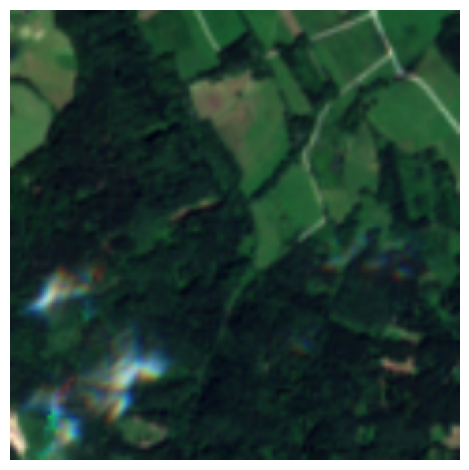

In [19]:
torchshow.show(dataset_train.__getitem__(10)[0])

In [28]:
val_dl = loader_dataloader(dataset_val,            
                                    batch_size= 16,
                                    shuffle = False,
                                    num_workers = 4,
                                    pin_memory = True)

In [29]:
def get_batch_n(dataloader, n):
    """Get the nth batch from dataloader"""
    iterator = iter(dataloader)
    for i in range(n + 1):
        batch = next(iterator)
    return batch


In [130]:
bqtch = get_batch_n(train_dl,2)

In [ ]:
for i in range(2):
    batch = next(iter(train_dl))

SyntaxError: invalid syntax (2634990927.py, line 1)

In [30]:
def get_label_back(array_label):
    idx_to_label= {0: 'Agro-forestry areas',
                    1: 'Arable land',
                    2: 'Beaches, dunes, sands',
                    3: 'Broad-leaved forest',
                    4: 'Coastal wetlands',
                    5: 'Complex cultivation patterns',
                    6: 'Coniferous forest',
                    7: 'Industrial or commercial units',
                    8: 'Inland waters',
                    9: 'Inland wetlands',
                    10: 'Land principally occupied by agriculture, with significant areas of natural vegetation',
                    11: 'Marine waters',
                    12: 'Mixed forest',
                    13: 'Moors, heathland and sclerophyllous vegetation',
                    14: 'Natural grassland and sparsely vegetated areas',
                    15: 'Pastures',
                    16: 'Permanent crops',
                    17: 'Transitional woodland, shrub',
                    18: 'Urban fabric'}
    label_list = []
    for i,pos in enumerate(array_label):
        if int(pos)==1:
            label_list.append(idx_to_label[i])
    return label_list
    

In [78]:
get_label_back(batch[1][0].numpy())

['Broad-leaved forest',
 'Coniferous forest',
 'Inland waters',
 'Mixed forest',
 'Pastures']

In [40]:
import numpy as np
def plot_batch(batch,ncols=4, figsize=(15, 10)):
    """
    Plot images from a batch with their corresponding labels.
    
    Args:
        batch: Tuple of (images, labels) from dataloader
        num_samples: Number of samples to display (default: 8)
        figsize: Figure size for the plot (default: (15, 10))
    """
    images, labels = batch
    
    rows = int(images.shape[0]/ncols)
    cols = ncols
    num_samples = int(images.shape[0])

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    for idx in range(num_samples):
        row = idx // rows
        col = idx % cols
        ax = axes[row, col]
        
        if idx < len(images):
            # Handle image data
            img = images[idx].numpy()
            
            imgm =  np.transpose(img, (2,1,0))

            # Normalize to 0-1 range for display
            imgm_normalized = (imgm - imgm.min()) / (imgm.max() - imgm.min())

            ax.imshow(imgm_normalized)
            ##ax.imshow(imgm)
            # Get and display labels
            label_array = labels[idx]
            label_names = get_label_back(label_array.numpy())
            
            # Format labels for display
            if len(label_names) > 2:
                title = f"{', '.join(label_names[:2])}\n+{label_names[2:4]}\n+{len(label_names)-4} more"
            else:
                title = ', '.join(label_names)
            
            ax.set_title(title, fontsize=10, wrap=True)
            ax.axis('off')
        else:
            # Hide empty subplots
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [32]:
batch = get_batch_n(train_dl,0)

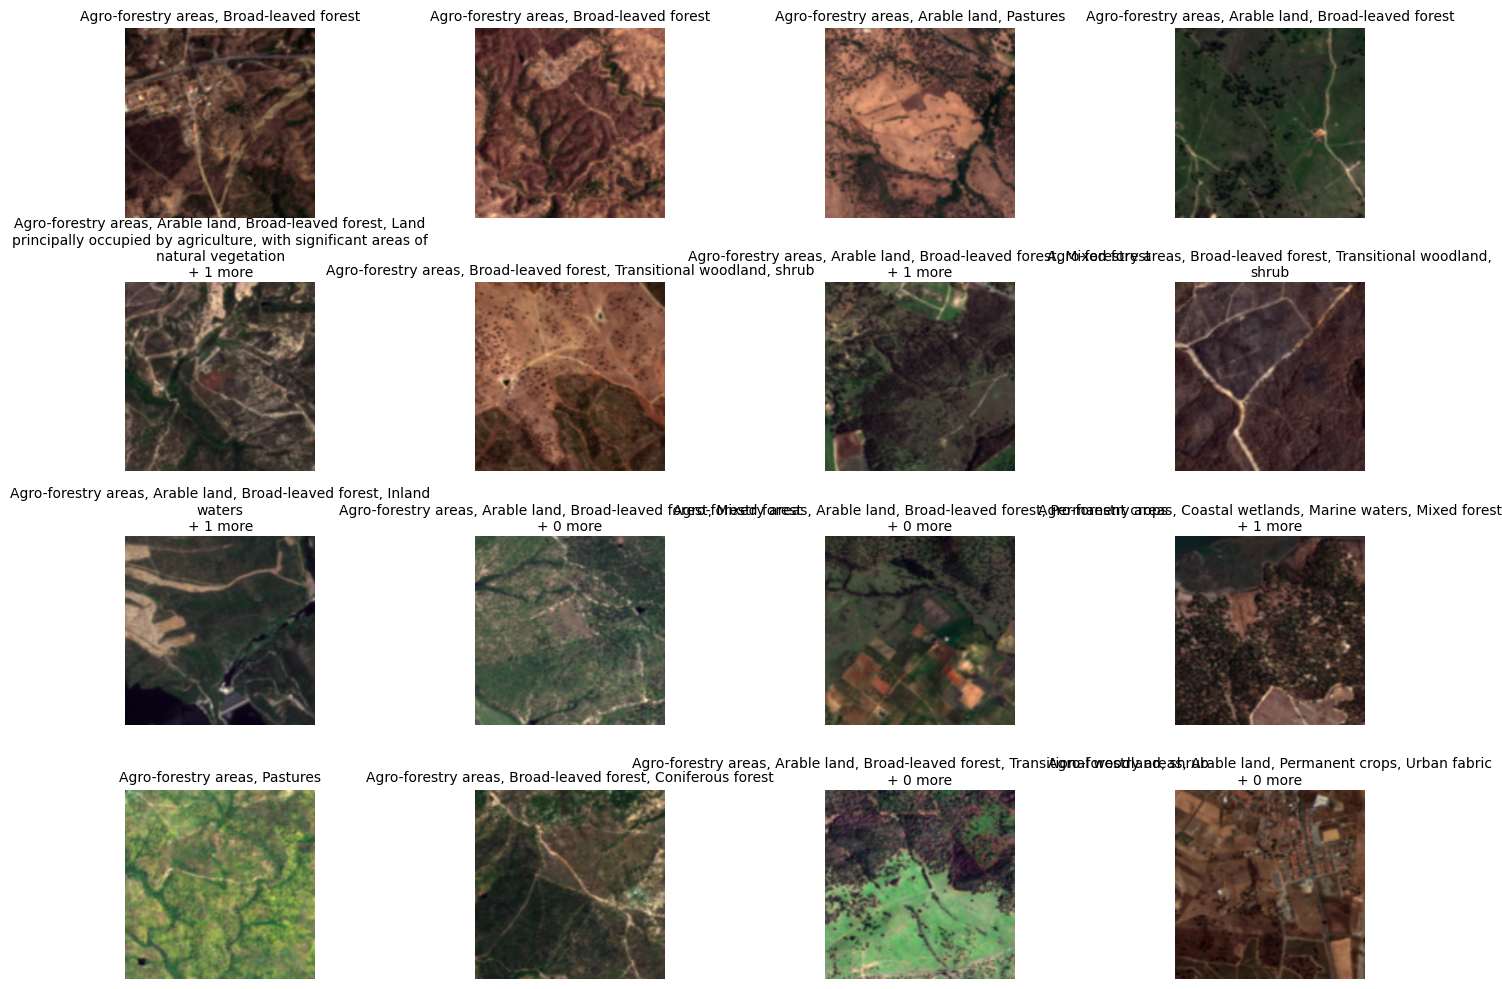

In [33]:
plot_batch(batch)

In [38]:
batch = get_batch_n(train_dl,12)

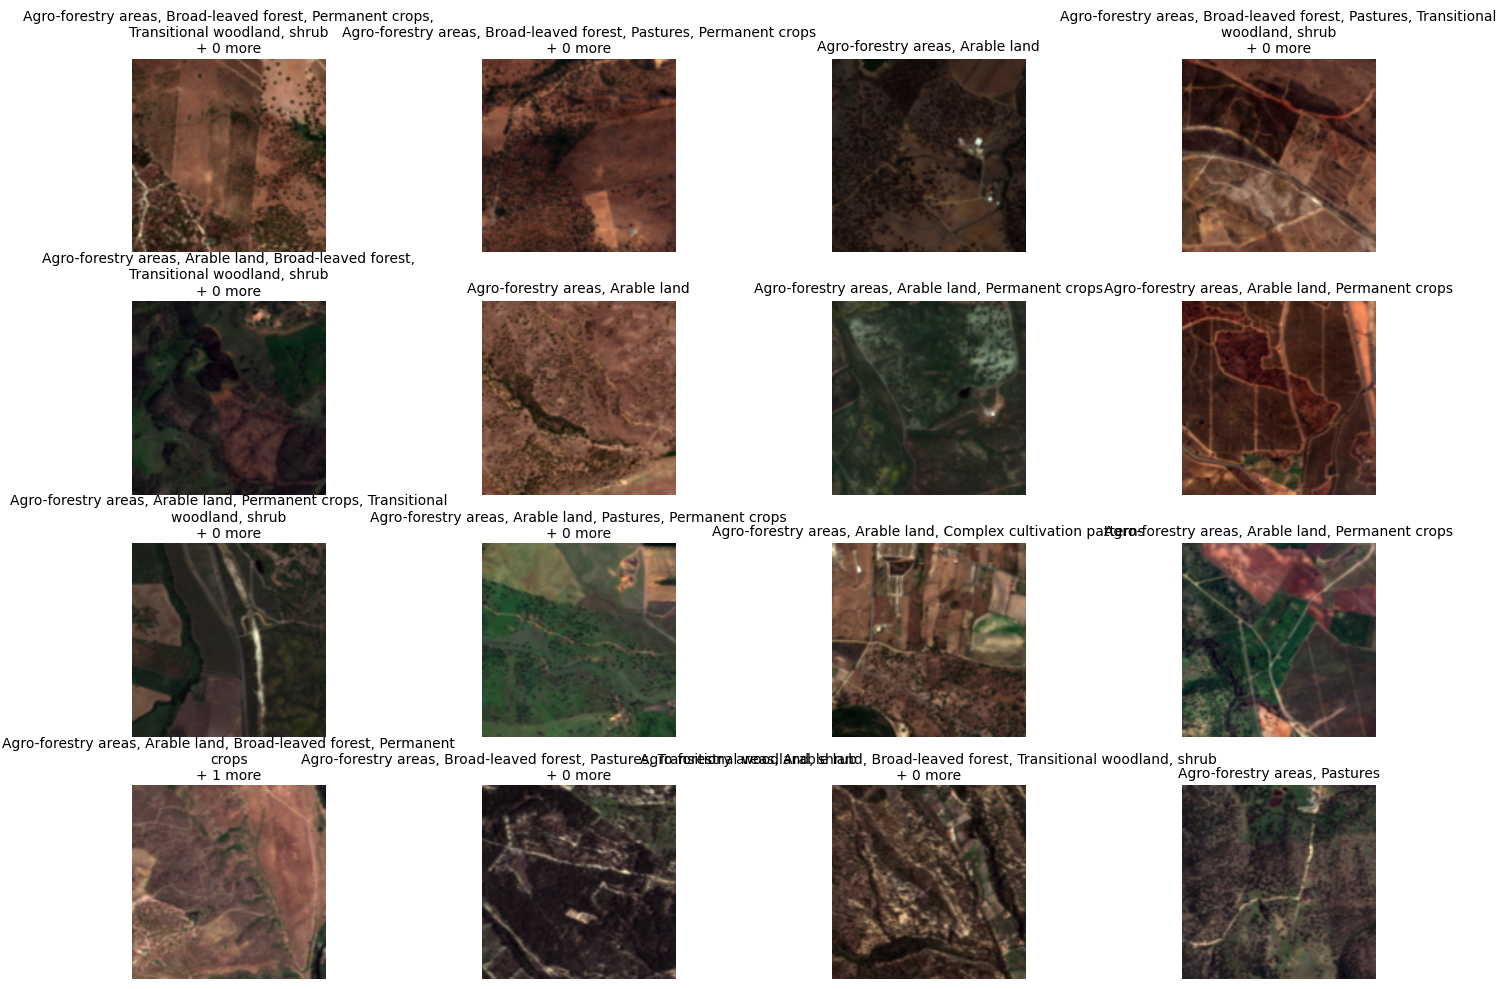

In [39]:
plot_batch(batch)

In [41]:
batch1 = get_batch_n(train_dl,50)

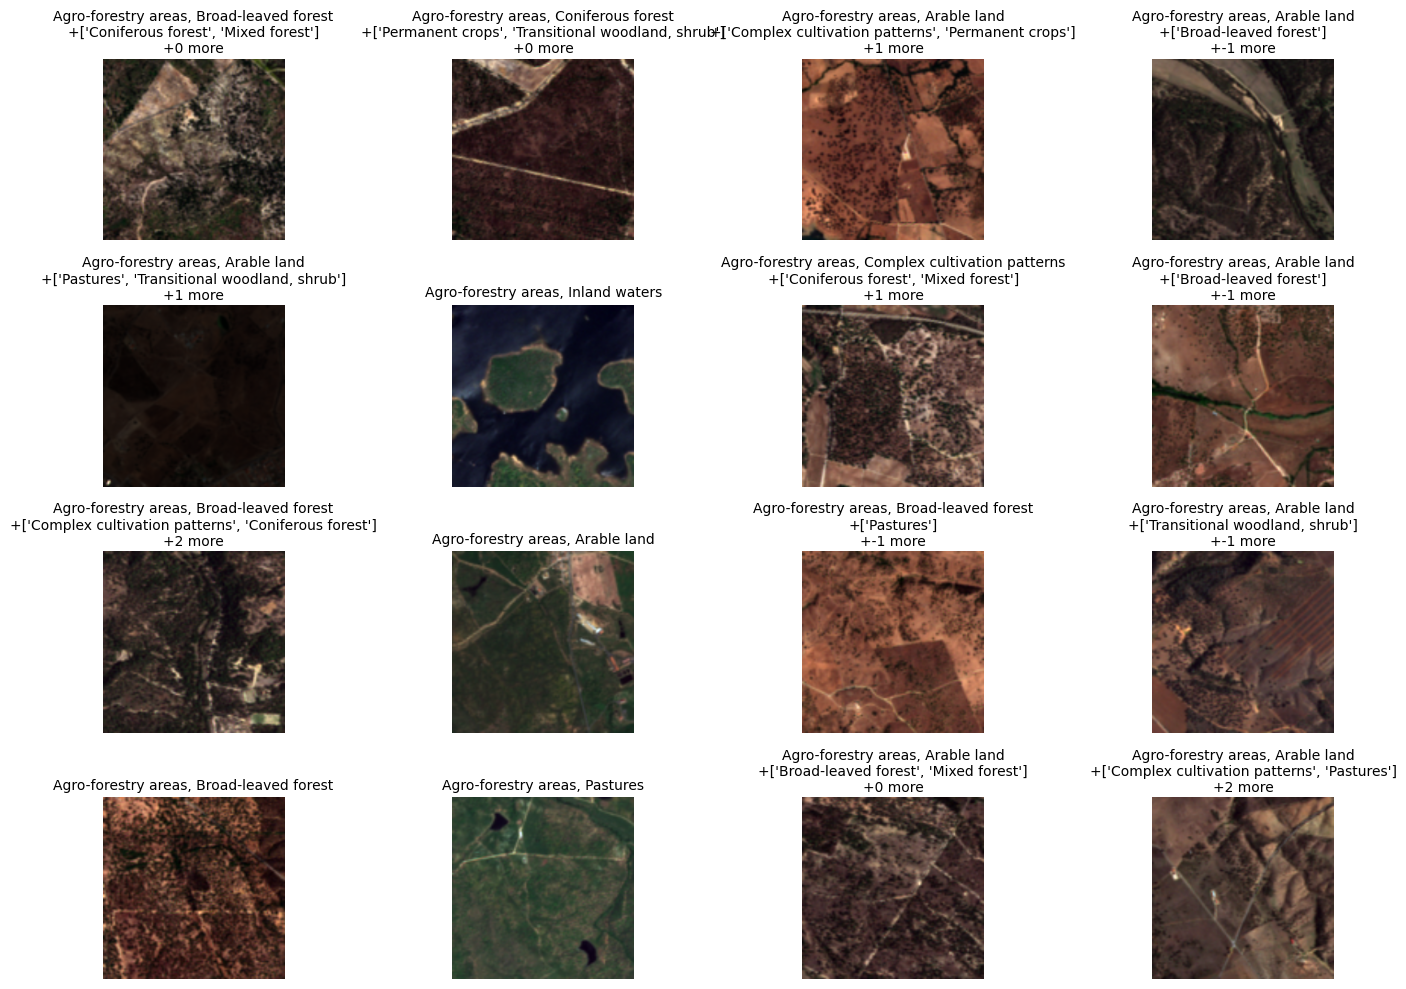

In [42]:
plot_batch(batch1)

In [40]:
x_sample = batch[0][0]  # First image, all channels
print(f"Channel 0 (should be Red/B04) stats: mean={x_sample[0].mean():.3f}, std={x_sample[0].std():.3f}")
print(f"Channel 1 (should be Green/B03) stats: mean={x_sample[1].mean():.3f}, std={x_sample[1].std():.3f}")
print(f"Channel 2 (should be Blue/B02) stats: mean={x_sample[2].mean():.3f}, std={x_sample[2].std():.3f}")

Channel 0 (should be Red/B04) stats: mean=-0.293, std=0.394
Channel 1 (should be Green/B03) stats: mean=-0.063, std=0.396
Channel 2 (should be Blue/B02) stats: mean=-0.164, std=0.348


In [48]:
x_sample = batch[0][0]  # First image, all channels
print(f"Channel 0 (should be Red/B04) stats: mean={x_sample[0].mean():.3f}, std={x_sample[0].std():.3f}")
print(f"Channel 1 (should be Green/B03) stats: mean={x_sample[1].mean():.3f}, std={x_sample[1].std():.3f}")
print(f"Channel 2 (should be Blue/B02) stats: mean={x_sample[2].mean():.3f}, std={x_sample[2].std():.3f}")

Channel 0 (should be Red/B04) stats: mean=387.801, std=269.593
Channel 1 (should be Green/B03) stats: mean=576.032, std=239.178
Channel 2 (should be Blue/B02) stats: mean=338.800, std=211.374


In [41]:
list_mean, list_std

([588.4096069335938, 614.0556640625, 438.3720703125],
 [684.56884765625, 603.2968139648438, 607.02685546875])

In [35]:
batch[0]

tensor([[[[ 5.5157e-01,  4.6333e-01,  3.0760e-01,  ...,  1.1645e+00,
            1.4353e+00,  1.5887e+00],
          [ 6.1632e-01,  5.4705e-01,  4.2482e-01,  ...,  1.1872e+00,
            1.4656e+00,  1.6233e+00],
          [ 7.3057e-01,  6.9480e-01,  6.3168e-01,  ...,  1.2272e+00,
            1.5190e+00,  1.6844e+00],
          ...,
          [ 2.3639e-01,  2.1758e-01,  1.8439e-01,  ...,  1.3469e+00,
            1.4308e+00,  1.4784e+00],
          [ 4.0307e-01,  3.2749e-01,  1.9410e-01,  ...,  1.0489e+00,
            1.2561e+00,  1.3735e+00],
          [ 4.9753e-01,  3.8977e-01,  1.9961e-01,  ...,  8.8009e-01,
            1.1571e+00,  1.3141e+00]],

         [[ 4.6734e-01,  4.4822e-01,  4.1448e-01,  ...,  1.9597e+00,
            2.1604e+00,  2.2741e+00],
          [ 5.6194e-01,  5.4129e-01,  5.0485e-01,  ...,  1.9348e+00,
            2.1263e+00,  2.2348e+00],
          [ 7.2888e-01,  7.0553e-01,  6.6434e-01,  ...,  1.8909e+00,
            2.0662e+00,  2.1656e+00],
          ...,
     

In [7]:
idx_to_label={}
for i,v in label_to_idx.items():
    idx_to_label[v]=i

In [5]:
label_to_idx

{'Agro-forestry areas': 0,
 'Arable land': 1,
 'Beaches, dunes, sands': 2,
 'Broad-leaved forest': 3,
 'Coastal wetlands': 4,
 'Complex cultivation patterns': 5,
 'Coniferous forest': 6,
 'Industrial or commercial units': 7,
 'Inland waters': 8,
 'Inland wetlands': 9,
 'Land principally occupied by agriculture, with significant areas of natural vegetation': 10,
 'Marine waters': 11,
 'Mixed forest': 12,
 'Moors, heathland and sclerophyllous vegetation': 13,
 'Natural grassland and sparsely vegetated areas': 14,
 'Pastures': 15,
 'Permanent crops': 16,
 'Transitional woodland, shrub': 17,
 'Urban fabric': 18}

In [8]:
idx_to_label

{0: 'Agro-forestry areas',
 1: 'Arable land',
 2: 'Beaches, dunes, sands',
 3: 'Broad-leaved forest',
 4: 'Coastal wetlands',
 5: 'Complex cultivation patterns',
 6: 'Coniferous forest',
 7: 'Industrial or commercial units',
 8: 'Inland waters',
 9: 'Inland wetlands',
 10: 'Land principally occupied by agriculture, with significant areas of natural vegetation',
 11: 'Marine waters',
 12: 'Mixed forest',
 13: 'Moors, heathland and sclerophyllous vegetation',
 14: 'Natural grassland and sparsely vegetated areas',
 15: 'Pastures',
 16: 'Permanent crops',
 17: 'Transitional woodland, shrub',
 18: 'Urban fabric'}